In [2]:
import numpy as np
import seaborn as sns
from utils import *
import warnings
from xgboost import XGBClassifier
from sklearn.ensemble      import GradientBoostingClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import SVC
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base          import clone
from sklearn.metrics       import roc_auc_score, precision_score, recall_score, f1_score


sns.set(style="whitegrid")
warnings.filterwarnings("ignore")

data_path = "Data\\BL_M_combined.csv"

# Load the data
data_M = get_data(data_path)

# Get column names
dem_clinic_features, left, right, all_features = get_columns_names()
target_column = 'pain improvement percentage' # We will use this column to define treatment success

random_forest_scores = []
feature_importance_dict_rf = {key: 0.0 for key in all_features}
feature_importance_dict_shap = {key: 0.0 for key in all_features}
random_seeds = np.arange(0, 100)
threshold = 0.20

# Data partitioning
data_main = data_M
data_main = data_main[(data_main[target_column] <= 0) | (data_main[target_column] >= threshold)]  # Filter remaining values

Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
Seed: 5
Seed: 6
Seed: 7
Seed: 8
Seed: 9
Seed: 10
Seed: 11
Seed: 12
Seed: 13
Seed: 14
Seed: 15
Seed: 16
Seed: 17
Seed: 18
Seed: 19
Seed: 20
Seed: 21
Seed: 22
Seed: 23
Seed: 24
Seed: 25
Seed: 26
Seed: 27
Seed: 28
Seed: 29
Seed: 30
Seed: 31
Seed: 32
Seed: 33
Seed: 34
Seed: 35
Seed: 36
Seed: 37
Seed: 38
Seed: 39
Seed: 40
Seed: 41
Seed: 42
Seed: 43
Seed: 44
Seed: 45
Seed: 46
Seed: 47
Seed: 48
Seed: 49
Seed: 50
Seed: 51
Seed: 52
Seed: 53
Seed: 54
Seed: 55
Seed: 56
Seed: 57
Seed: 58
Seed: 59
Seed: 60
Seed: 61
Seed: 62
Seed: 63
Seed: 64
Seed: 65
Seed: 66
Seed: 67
Seed: 68
Seed: 69
Seed: 70
Seed: 71
Seed: 72
Seed: 73
Seed: 74
Seed: 75
Seed: 76
Seed: 77
Seed: 78
Seed: 79
Seed: 80
Seed: 81
Seed: 82
Seed: 83
Seed: 84
Seed: 85
Seed: 86
Seed: 87
Seed: 88
Seed: 89
Seed: 90
Seed: 91
Seed: 92
Seed: 93
Seed: 94
Seed: 95
Seed: 96
Seed: 97
Seed: 98
Seed: 99


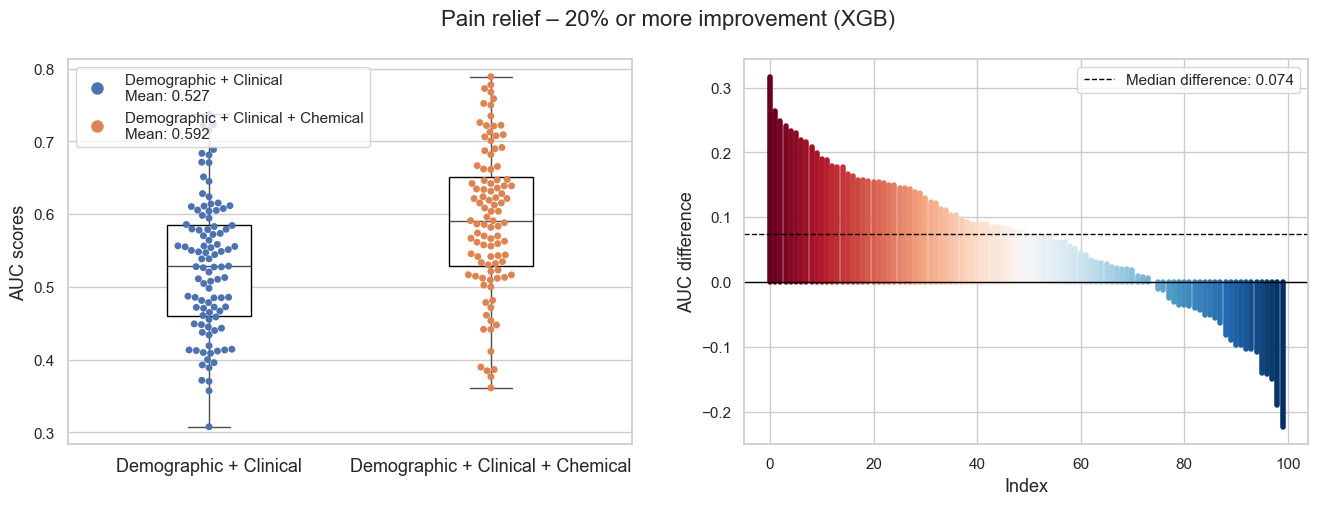

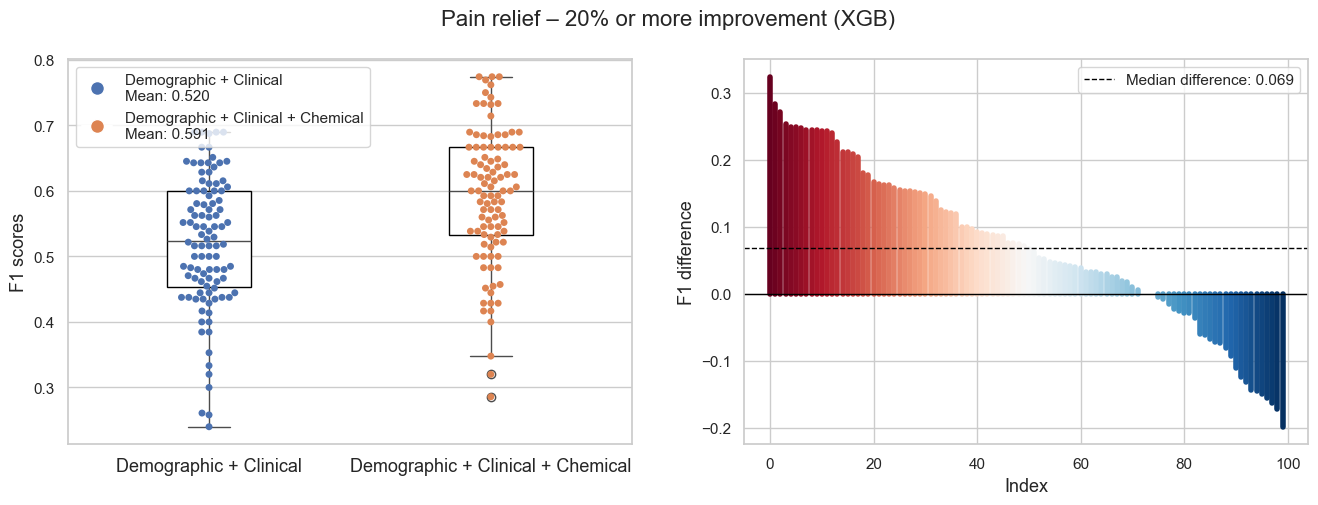

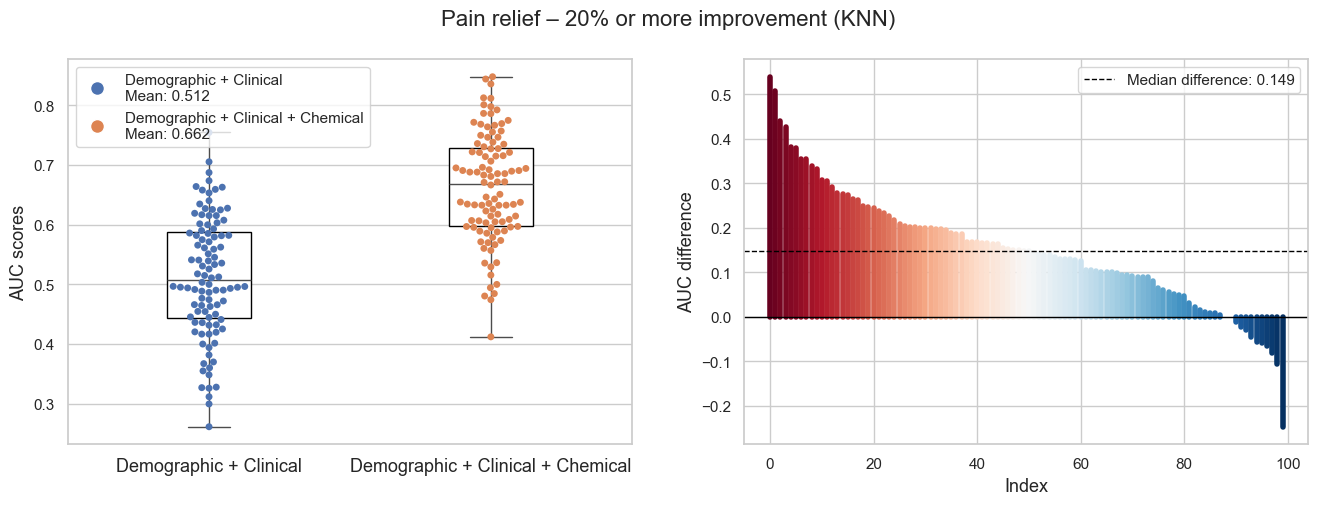

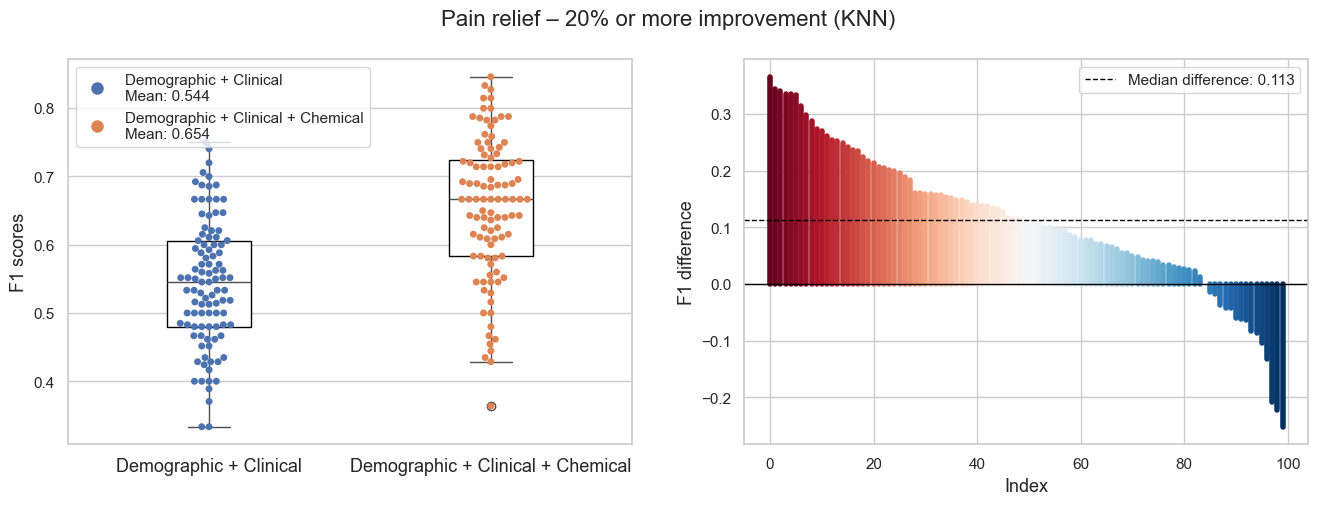

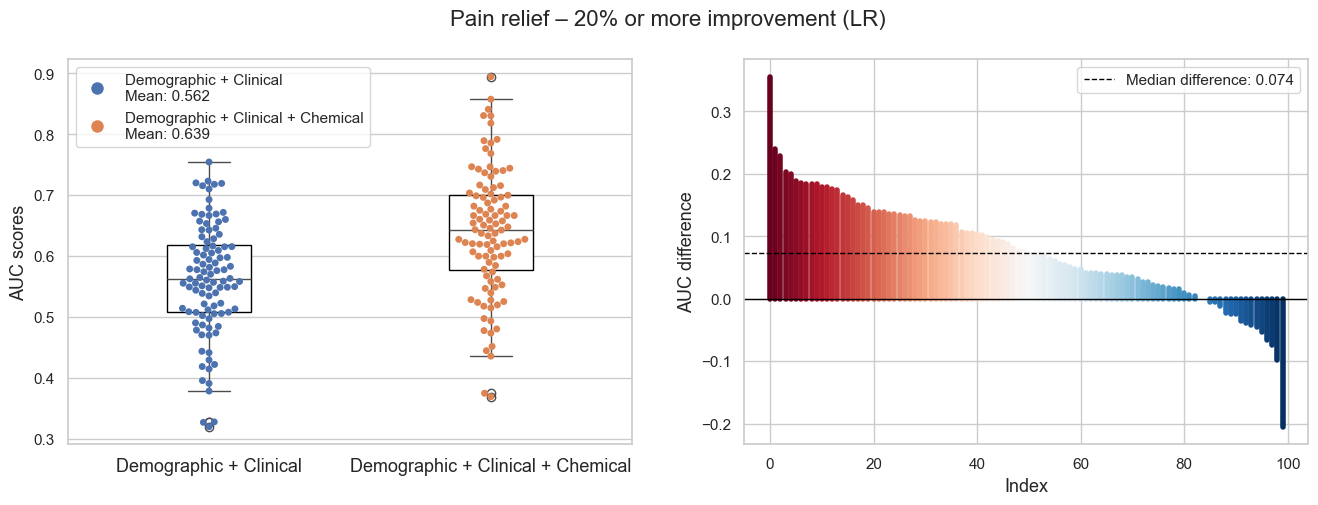

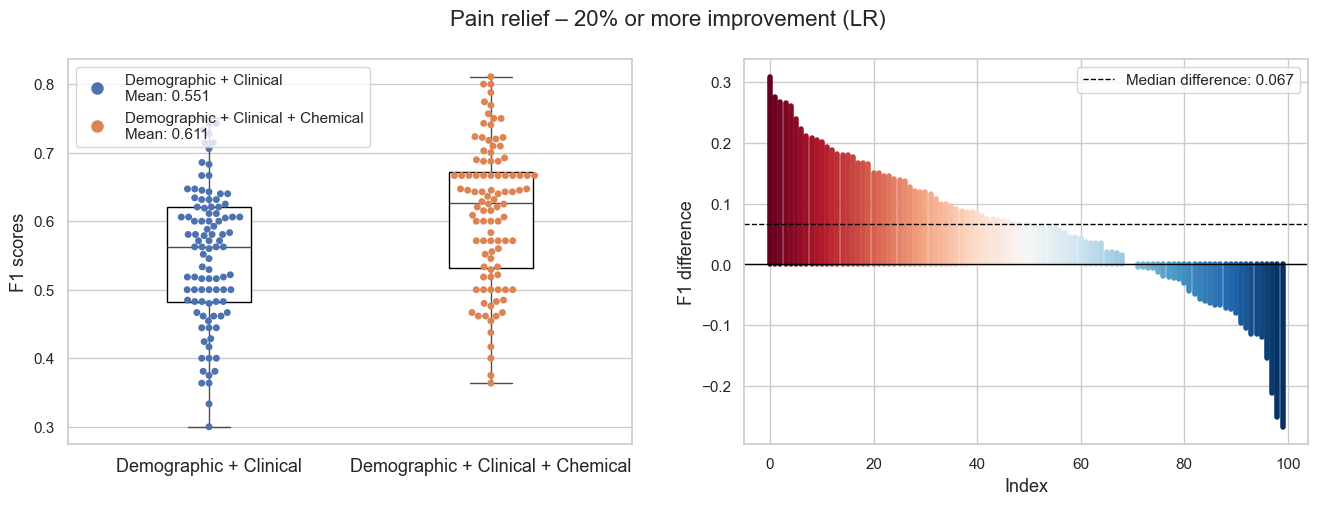

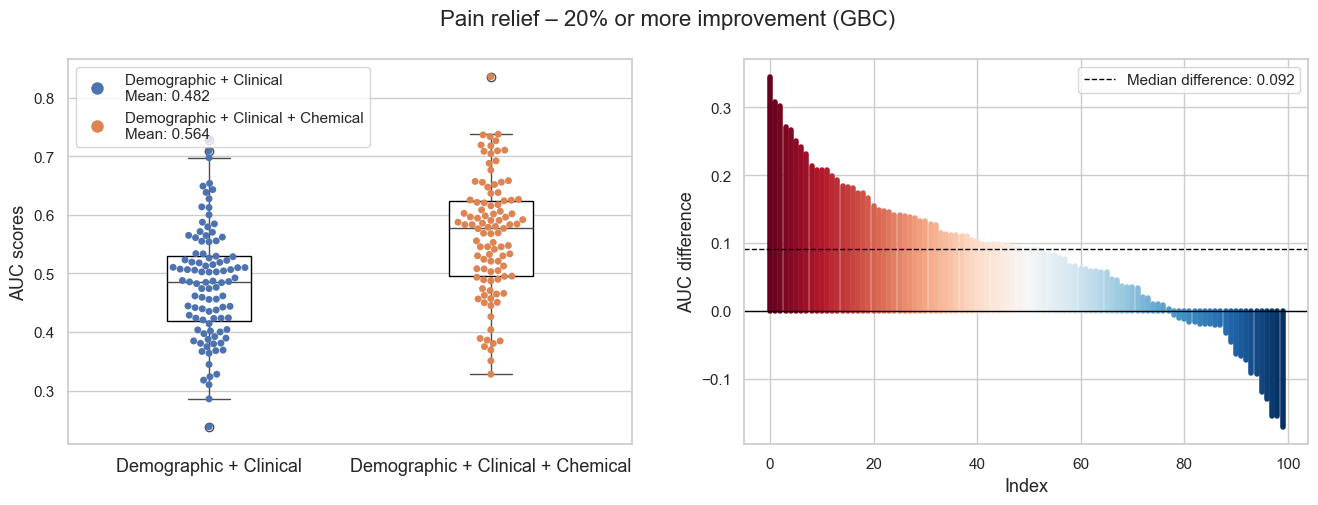

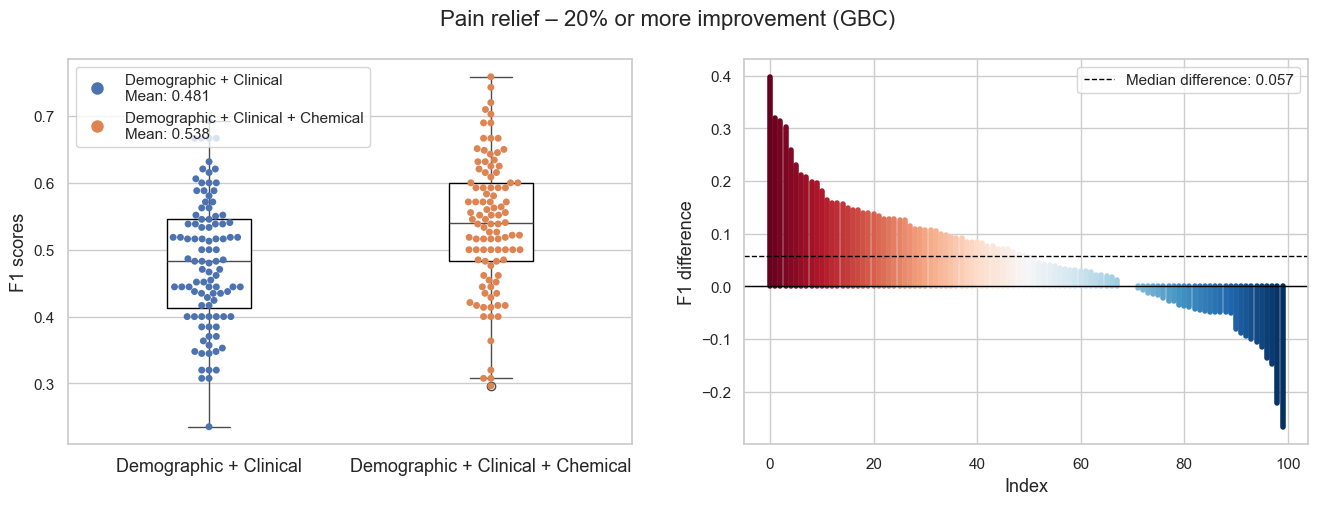

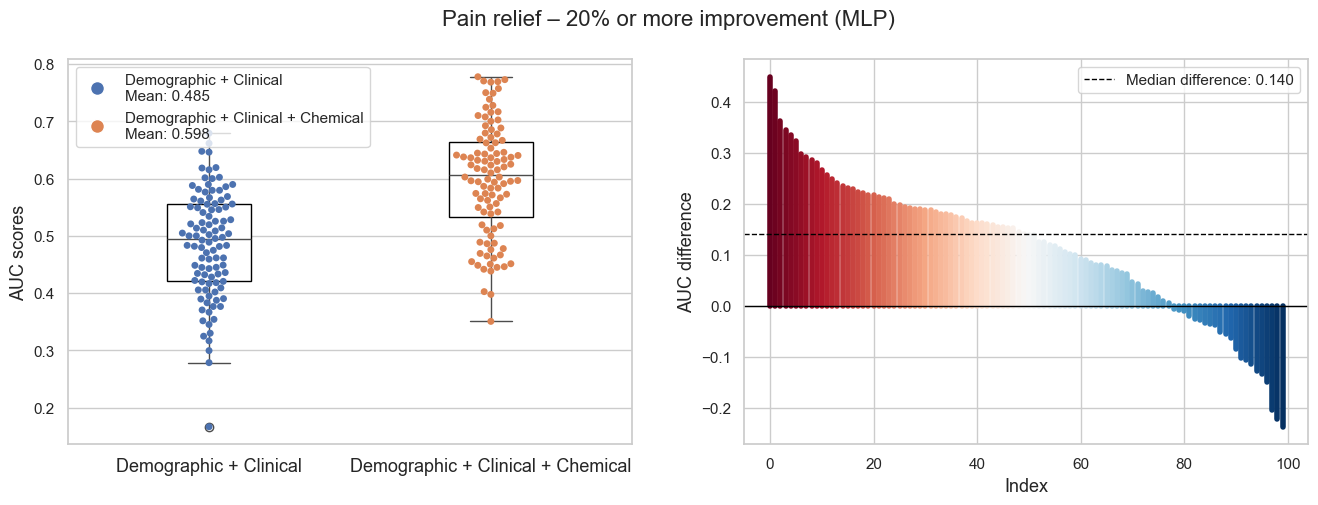

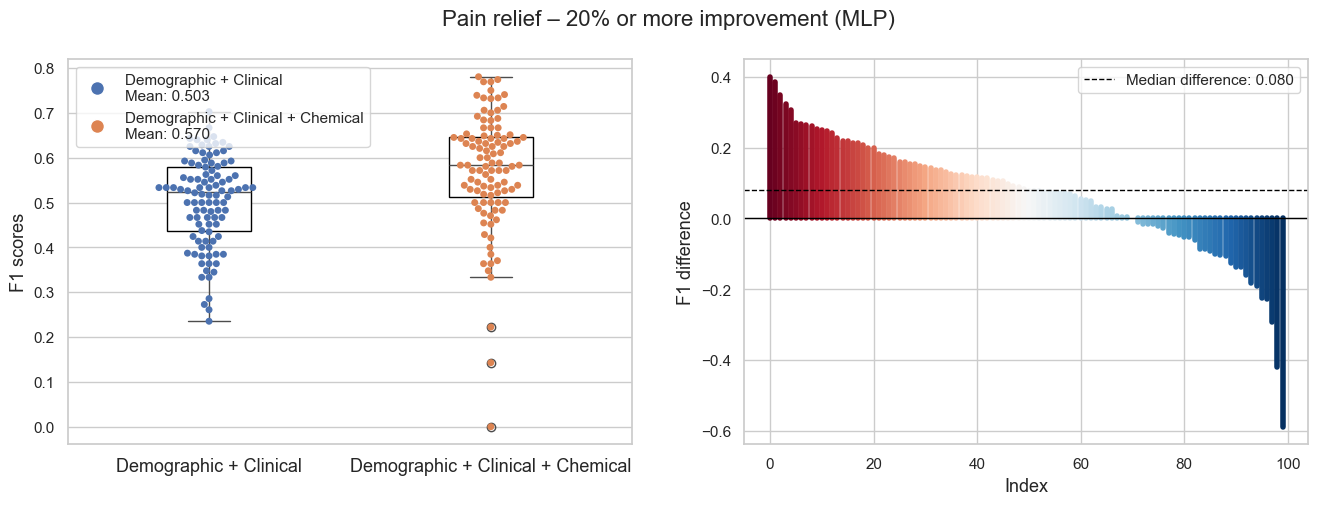

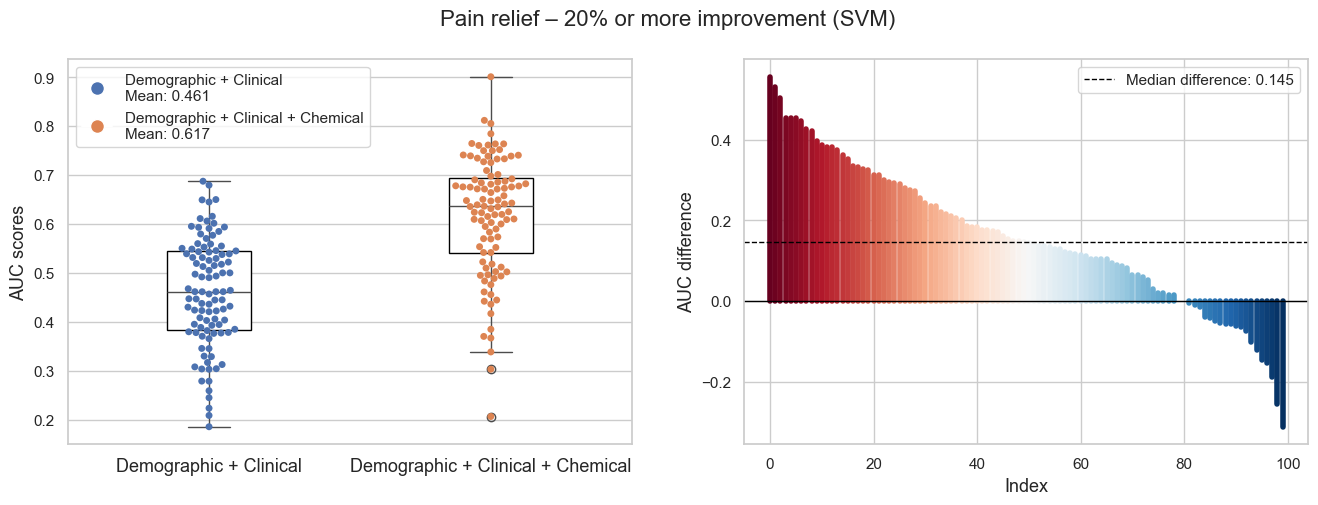

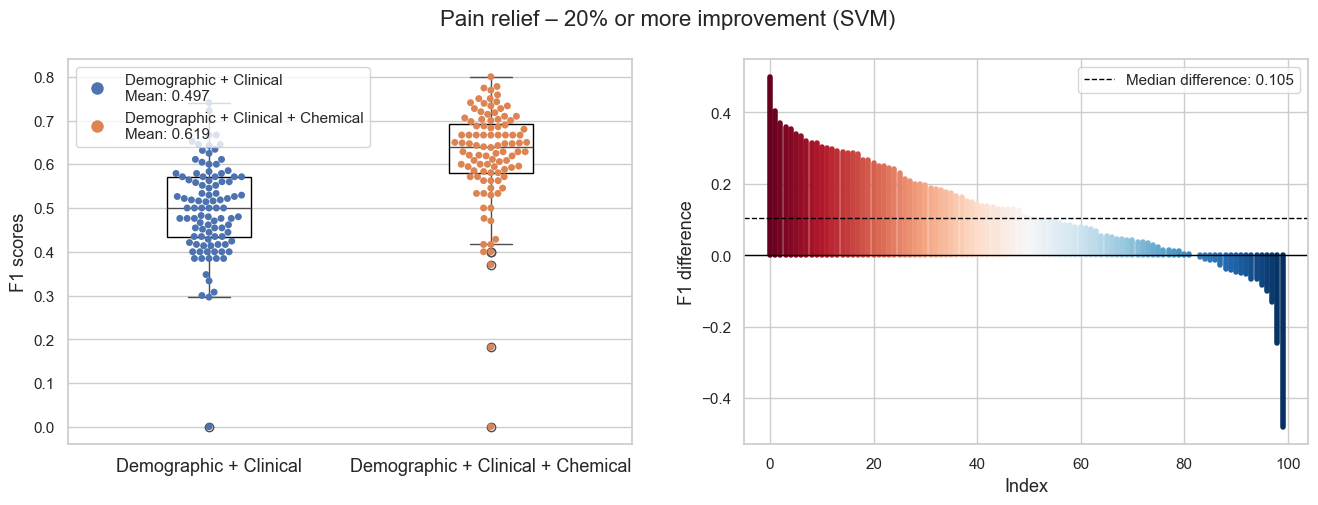

In [5]:
random_seeds = range(100)

models = {
    'XGB' : XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=0),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'LR'  : LogisticRegression(max_iter=1000, random_state=0),
    'GBC' : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0),
    'MLP' : MLPClassifier(hidden_layer_sizes=(100,100), max_iter=500, random_state=0),
    'SVM' : SVC(probability=True, random_state=0)
}

all_scores = { name: [] for name in models }

for seed in random_seeds:
    print(f"Seed: {seed}")
    # Shuffle & split
    shuffled = data_main.sample(frac=1, random_state=seed)
    n_train  = int(0.75 * len(shuffled))
    train_df = shuffled.iloc[:n_train].copy()
    test_df  = shuffled.iloc[n_train:].copy()

    # Feature selection
    left_feats, _  = get_feature_importance(train_df, target_column, left, 10, threshold)
    right_feats, _ = get_feature_importance(train_df, target_column, right,10, threshold)
    chem_feats     = np.concatenate([left_feats, right_feats])
    demo_feats, _  = get_feature_importance(train_df, target_column, dem_clinic_features, len(dem_clinic_features)-1, threshold)
    all_feats      = np.concatenate([chem_feats, demo_feats, np.array([target_column])])

    train_df = train_df[all_feats].dropna()
    test_df  = test_df [all_feats].dropna()

    # Prepare X and continuous y
    X_train_cont = train_df.drop(target_column, axis=1)
    y_train = train_df[target_column].apply(transform_column, threshold=threshold)
    X_test_cont  = test_df .drop(target_column, axis=1)
    y_test  = test_df [target_column].apply(transform_column, threshold=threshold)

    # 2.4) **Binarize** the continuous target for classification
    # y_train = y_train
    # y_test  = y_test.apply(transform_column, threshold=threshold)

    # Train & evaluate each model on Dem+Clin vs All
    for name, base in models.items():
        dem_scores, chem_scores = {}, {}

        # Demographic + Clinical only
        clf = clone(base)
        if hasattr(clf, 'random_state'):
            setattr(clf, 'random_state', seed)
        clf.fit(X_train_cont[demo_feats], y_train)
        y_pred = clf.predict(X_test_cont[demo_feats])
        y_prob = clf.predict_proba(X_test_cont[demo_feats])[:,1]
        dem_scores = {
            'AUC'      : roc_auc_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred),
            'Recall'   : recall_score(y_test, y_pred),
            'F1'       : f1_score(y_test, y_pred)
        }

        # Demographic + Clinical + Chemical
        clf = clone(base)
        if hasattr(clf, 'random_state'):
            setattr(clf, 'random_state', seed)
        clf.fit(X_train_cont, y_train)
        y_pred = clf.predict(X_test_cont)
        y_prob = clf.predict_proba(X_test_cont)[:,1]
        chem_scores = {
            'AUC'      : roc_auc_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred),
            'Recall'   : recall_score(y_test, y_pred),
            'F1'       : f1_score(y_test, y_pred)
        }

        all_scores[name].append((dem_scores, chem_scores))

metrics_names   = ['AUC','F1']
base_titles     = ['Demographic + Clinical','Demographic + Clinical + Chemical']
main_plot_title = f"Pain relief – {int(threshold*100)}% or more improvement"

for name, score_list in all_scores.items():
    title = f"{main_plot_title} ({name})"
    for metric in metrics_names:
        arr = np.array([[d[metric], c[metric]] for d,c in score_list])
        plot_waterfall_and_beeswarm(
            arr,
            [arr[:,0], arr[:,1]],
            '',
            '',
            base_titles,
            title,
            metric
        )